In [9]:
from roboflow import Roboflow
from dotenv import load_dotenv
import os
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

load_dotenv("apikeys.env")

api_key = os.getenv("ROBOFLOW_API_KEY")

In [2]:
#Download the data
rf = Roboflow(api_key=api_key)
project = rf.workspace("roboflow-jvuqo").project("football-players-detection-3zvbc")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...


loading Roboflow project...


In [5]:
# Load a model
model = YOLO("yolo26n.pt")  # load a pretrained model (recommended for training)
# Train the model
results = model.train(data="/teamspace/studios/this_studio/AIClass/InteligenciaArtificialIS/Lecture09/notebooks/yolo/football-players-detection-1/data.yaml", epochs=20)

New https://pypi.org/project/ultralytics/8.4.34 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.4.23 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/teamspace/studios/this_studio/AIClass/InteligenciaArtificialIS/Lecture09/notebooks/yolo/football-players-detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, 

In [7]:
image_path = "football-players-detection-1/test/images/4b770a_1_4_png.rf.5a45b3b841a06de414ceb802e34c136f.jpg"
resultados = model(image_path)


image 1/1 /teamspace/studios/this_studio/AIClass/InteligenciaArtificialIS/Lecture09/notebooks/yolo/football-players-detection-1/test/images/4b770a_1_4_png.rf.5a45b3b841a06de414ceb802e34c136f.jpg: 384x640 1 goalkeeper, 22 players, 3 referees, 122.2ms
Speed: 2.6ms preprocess, 122.2ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)


In [8]:
r = resultados[0] # r es un objeto de tipo 'ultralytics.yolo.engine.results.Results' que contiene toda la informacion de la inferencia

print("=== Informacion general ===")
print(f"Imagen original: {r.path}")
print(f"Tamano procesado: {r.orig_shape}")
print(f"Objetos detectados: {len(r.boxes)}")


print("\n=== Detecciones ===")
for i, box in enumerate(r.boxes):
    clase_id  = int(box.cls[0])
    clase_nom = model.names[clase_id]
    confianza = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    
    print(f"  [{i+1}] {clase_nom:15s} | confianza: {confianza:.2f} | bbox: ({x1:.0f},{y1:.0f}) → ({x2:.0f},{y2:.0f})")

=== Informacion general ===
Imagen original: /teamspace/studios/this_studio/AIClass/InteligenciaArtificialIS/Lecture09/notebooks/yolo/football-players-detection-1/test/images/4b770a_1_4_png.rf.5a45b3b841a06de414ceb802e34c136f.jpg
Tamano procesado: (1080, 1920)
Objetos detectados: 26

=== Detecciones ===
  [1] player          | confianza: 0.97 | bbox: (1719,627) → (1757,715)
  [2] player          | confianza: 0.96 | bbox: (1573,457) → (1613,530)
  [3] player          | confianza: 0.94 | bbox: (628,368) → (654,423)
  [4] player          | confianza: 0.92 | bbox: (738,403) → (762,467)
  [5] player          | confianza: 0.91 | bbox: (1016,324) → (1038,375)
  [6] player          | confianza: 0.91 | bbox: (1499,393) → (1534,459)
  [7] player          | confianza: 0.90 | bbox: (946,313) → (963,358)
  [8] player          | confianza: 0.86 | bbox: (571,707) → (632,818)
  [9] player          | confianza: 0.85 | bbox: (1376,325) → (1397,375)
  [10] goalkeeper      | confianza: 0.83 | bbox: (66,36

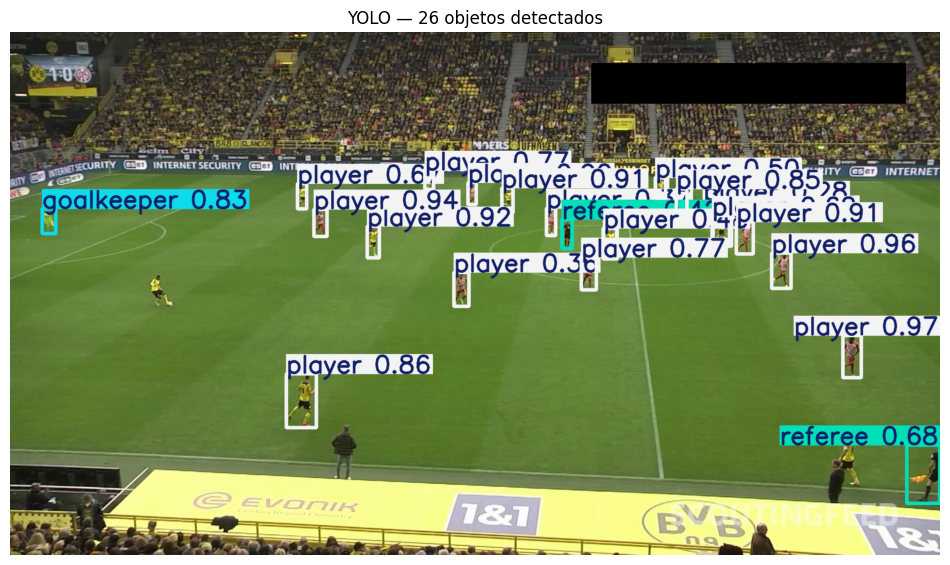

In [10]:

# r.plot() retorna la imagen anotada como array NumPy (BGR → convertir a RGB para matplotlib)
imagen_anotada = r.plot()
imagen_anotada_rgb = imagen_anotada[:, :, ::-1]  # BGR a RGB

plt.figure(figsize=(12, 7))
plt.imshow(imagen_anotada_rgb)
plt.title(f"YOLO — {len(r.boxes)} objetos detectados")
plt.axis("off")
plt.show()